In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

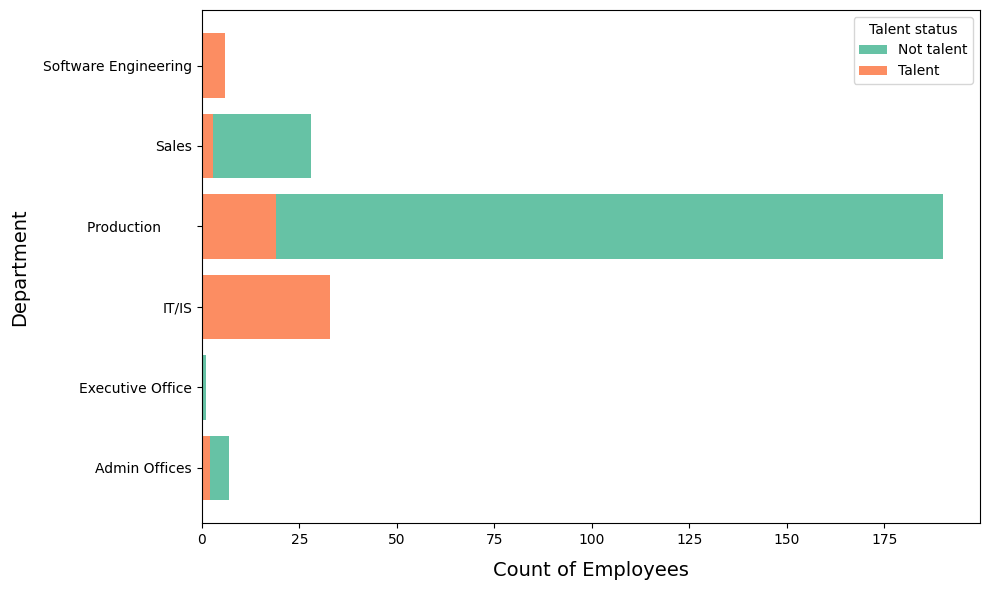

In [3]:
# Map is_talent to readable labels (optional)
df["TalentStatus"] = df["is_talent"].map({0: "Not talent", 1: "Talent"})

# Aggregate counts per department and talent status
dept_counts = (
    df.groupby(["Department", "TalentStatus"])
      .size()
      .unstack(fill_value=0)      # columns: "Not talent", "Talent"
)

# Ensure consistent column order
dept_counts = dept_counts[["Not talent", "Talent"]]

palette = sns.color_palette("Set2", n_colors=2)

plt.figure(figsize=(10, 6))

for i, col in enumerate(dept_counts.columns):
    plt.barh(
        y=dept_counts.index,
        width=dept_counts[col],
        label=col,
        color=palette[i]
    )

plt.xlabel("Count of Employees", fontsize=14, labelpad=10)
plt.ylabel("Department", fontsize=14, labelpad=10)
plt.legend(title="Talent status")
plt.tight_layout()
plt.show()